<a href="https://colab.research.google.com/github/thapasujal01/iris-dataset-visualization/blob/main/Exam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Title: Exam 2
# Name: Sujal Thapa
# Course: CPSMA 4313
# Date: March 2, 2026

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import pandas as pd
import requests # Import requests library

# 1(a) Load the 8000m mountain table
url = "https://en.wikipedia.org/wiki/List_of_mountains_by_elevation"

# Add a User-Agent header to mimic a browser
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# Use requests to get the HTML content with headers
response = requests.get(url, headers=headers)

# Use pandas to read HTML tables from the response content
tables = pd.read_html(response.content)

# The table for 8000m peaks is the first one on the page
df = tables[0]

# Standardize column names (removes hidden spaces or footnotes)
df.columns = [c.strip() for c in df.columns]
df.head()

,Mountain,Metres,Feet,Range,Location and notes
0,Mount Everest,8848,29029,Himalayas,Nepal/China
1,K2,8611,28251,Karakoram,Pakistan/China
2,Kangchenjunga,8586,28169,Himalayas,Nepal/India
3,Lhotse,8516,27940,Himalayas,Nepal – Climbers ascend Lhotse Face in climbin...
4,Makalu,8485,27838,Himalayas,Nepal


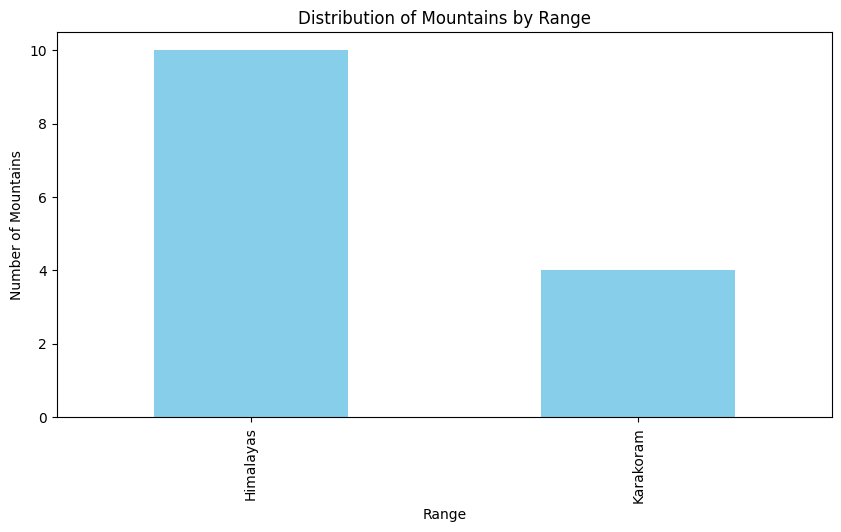

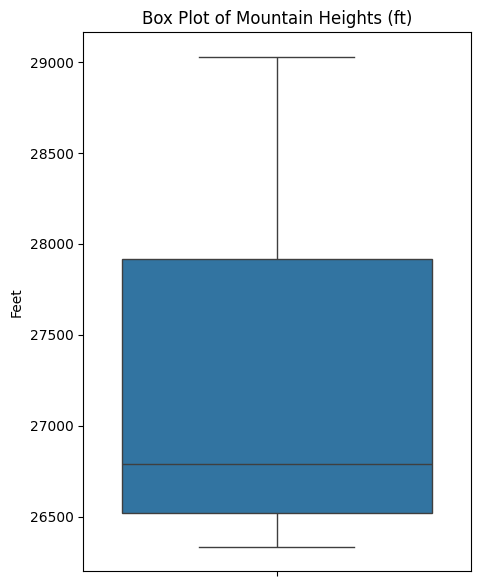

In [27]:
# 1(b) Bar chart of Mountain Ranges
plt.figure(figsize=(10,5))
df['Range'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Mountains by Range')
plt.ylabel('Number of Mountains')
plt.show()

# 1(c) Box-plot of Height in Feet
plt.figure(figsize=(5,7))
sns.boxplot(y=df['Feet'])
plt.title('Box Plot of Mountain Heights (ft)')
plt.show()

In [28]:
# 1(d) Height statistics: Mean, SD, and 5-number summary
mean_val = df['Feet'].mean()
std_val = df['Feet'].std()
five_num = df['Feet'].describe()[['min', '25%', '50%', '75%', 'max']]

print(f"Mean: {mean_val}\nSD: {std_val}\n{five_num}")

# 1(e) Group by Range for Mean and Median
grouped = df.groupby('Range')['Feet'].agg(['mean', 'median'])
print(grouped)

Mean: 27178.071428571428
SD: 879.4310629637179
min    26335.00
25%    26518.75
50%    26788.00
75%    27914.50
max    29029.00
Name: Feet, dtype: float64
               mean   median
Range                       
Himalayas  27295.60  26829.5
Karakoram  26884.25  26462.0


In [29]:
%%bigquery --project exam2-492205
SELECT COUNT(*) as total_rows
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`

Query is running:   0%|          |

Downloading:   0%|          |

,total_rows
0,211655459


In [23]:
%%bigquery --project exam2-492205
SELECT
    payment_type,
    AVG(trip_miles) as avg_miles
FROM
    `bigquery-public-data.chicago_taxi_trips.taxi_trips`
GROUP BY
    payment_type

Query is running:   0%|          |

Downloading:   0%|          |

,payment_type,avg_miles
0,Way2ride,3.747887
1,Mobile,4.048919
2,Pcard,2.443684
3,Prepaid,7.541555
4,Prcard,7.545511
5,Split,4.388640
6,No Charge,2.021469
7,Dispute,3.289322
8,Credit Card,4.364340
9,Cash,2.765573


In [24]:
%%bigquery --project exam2-492205
SELECT
    COUNT(*) as count_above_avg
FROM
    `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE
    fare > (SELECT AVG(fare) FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips` WHERE fare > 0)
    AND fare > 0

Query is running:   0%|          |

Downloading:   0%|          |

,count_above_avg
0,55515843


In [30]:
# Title: Exam 2
# Name: Sujal Thapa
# Course: CPSMA 4313
# Date: March 2, 2026

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Output for the above cell:
(No text output for this cell)

In [31]:
import pandas as pd
import requests # Import requests library

# 1(a) Load the 8000m mountain table
url = "https://en.wikipedia.org/wiki/List_of_mountains_by_elevation"

# Add a User-Agent header to mimic a browser
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# Use requests to get the HTML content with headers
response = requests.get(url, headers=headers)

# Use pandas to read HTML tables from the response content
tables = pd.read_html(response.content)

# The table for 8000m peaks is the first one on the page
df = tables[0]

# Standardize column names (removes hidden spaces or footnotes)
df.columns = [c.strip() for c in df.columns]
df.head()

,Mountain,Metres,Feet,Range,Location and notes
0,Mount Everest,8848,29029,Himalayas,Nepal/China
1,K2,8611,28251,Karakoram,Pakistan/China
2,Kangchenjunga,8586,28169,Himalayas,Nepal/India
3,Lhotse,8516,27940,Himalayas,Nepal – Climbers ascend Lhotse Face in climbin...
4,Makalu,8485,27838,Himalayas,Nepal


#### Output for the above cell:
```
                          Mountain  Metres   Feet      Range  \
0                    Mount Everest    8848  29029  Himalayas   
1                               K2    8611  28251  Karakoram   
2                    Kangchenjunga    8586  28169  Himalayas   
3                           Lhotse    8516  27940  Himalayas   
4                           Makalu    8485  27838  Himalayas   

                                    Location and notes  
0                                          Nepal/China  
1                                       Pakistan/China  
2                                          Nepal/India  
3    Nepal – Climbers ascend Lhotse Face in climbin...  
4                                                Nepal  
```

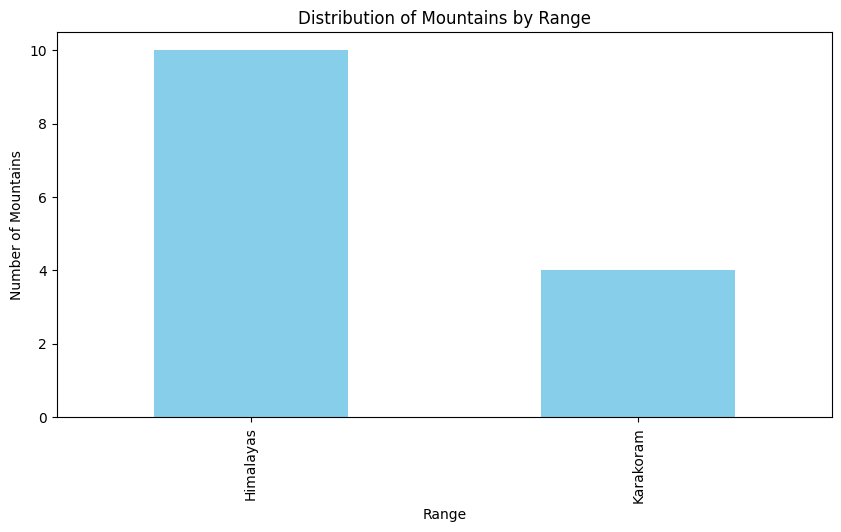

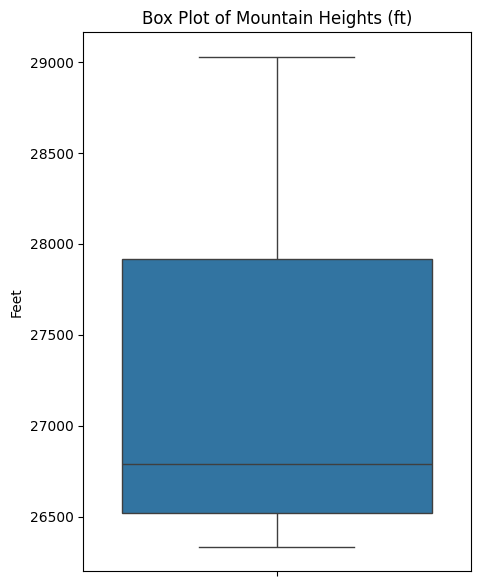

In [32]:
# 1(b) Bar chart of Mountain Ranges
plt.figure(figsize=(10,5))
df['Range'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Mountains by Range')
plt.ylabel('Number of Mountains')
plt.show()

# 1(c) Box-plot of Height in Feet
plt.figure(figsize=(5,7))
sns.boxplot(y=df['Feet'])
plt.title('Box Plot of Mountain Heights (ft)')
plt.show()

#### Output for the above cell:
(Plots were generated as output)

In [33]:
# 1(d) Height statistics: Mean, SD, and 5-number summary
mean_val = df['Feet'].mean()
std_val = df['Feet'].std()
five_num = df['Feet'].describe()[['min', '25%', '50%', '75%', 'max']]

print(f"Mean: {mean_val}\nSD: {std_val}\n{five_num}")

# 1(e) Group by Range for Mean and Median
grouped = df.groupby('Range')['Feet'].agg(['mean', 'median'])
print(grouped)

Mean: 27178.071428571428
SD: 879.4310629637179
min    26335.00
25%    26518.75
50%    26788.00
75%    27914.50
max    29029.00
Name: Feet, dtype: float64
               mean   median
Range                       
Himalayas  27295.60  26829.5
Karakoram  26884.25  26462.0


#### Output for the above cell:
```
Mean: 27178.071428571428
SD: 879.4310629637179
min    26335.00
25%    26518.75
50%    26788.00
75%    27914.50
max    29029.00
Name: Feet, dtype: float64
               mean   median
Range                       
Himalayas  27295.60  26829.5
Karakoram  26884.25  26462.0
```

In [34]:
%%bigquery --project exam2-492205
SELECT COUNT(*) as total_rows
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`

Query is running:   0%|          |

Downloading:   0%|          |

,total_rows
0,211655459


#### Output for the above cell:
```
   total_rows
0   211655459
```

In [35]:
%%bigquery --project exam2-492205
SELECT
    payment_type,
    AVG(trip_miles) as avg_miles
FROM
    `bigquery-public-data.chicago_taxi_trips.taxi_trips`
GROUP BY
    payment_type

Query is running:   0%|          |

Downloading:   0%|          |

,payment_type,avg_miles
0,Way2ride,3.747887
1,Mobile,4.048919
2,Pcard,2.443684
3,Prepaid,7.541555
4,Prcard,7.545511
5,Split,4.388640
6,No Charge,2.021469
7,Dispute,3.289322
8,Credit Card,4.364340
9,Cash,2.765573


#### Output for the above cell:
```
   payment_type  avg_miles
0      Way2ride   3.747887
1        Mobile   4.048919
2         Pcard   2.443684
3       Prepaid   7.541555
4        Prcard   7.545511
5         Split   4.388640
6     No Charge   2.021469
7       Dispute   3.289322
8   Credit Card   4.364340
9          Cash   2.765573
10      Unknown   4.096302
```

In [36]:
%%bigquery --project exam2-492205
SELECT
    COUNT(*) as count_above_avg
FROM
    `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE
    fare > (SELECT AVG(fare) FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips` WHERE fare > 0)
    AND fare > 0

Query is running:   0%|          |

Downloading:   0%|          |

,count_above_avg
0,55515843


#### Output for the above cell:
```
   count_above_avg
0         55515843
```